# Lab 5 - Tomás Pettit (G00419414)

**Module:** Artificial Intelligence  
**Topic:** Fuzzy Logic

## Learning Objectives

By the end of this lab, you will be able to:

1. Build a complete **Mamdani** fuzzy inference system from scratch (fuzzification → rule evaluation → aggregation → defuzzification)
2. Implement and compare **COG, MOM, SOM, and LOM** defuzzification methods
3. Use the **pyfuzzylite** library to build Mamdani, Sugeno, and Tsukamoto systems
4. Register custom hedges in pyfuzzylite to match the lecture slides' definitions
5. Understand the differences between the three inference methods
6. Generate 3D surface plots to visualise input-output relationships

---
## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import skfuzzy as fuzz

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Part A: Mamdani Inference from Scratch

We will implement the complete Mamdani inference pipeline step by step using the **project staffing** example from the lectures.

**Problem:** A project's **risk** depends on its **funding** level and **staffing** level.

**Linguistic variables:**

- **Funding** (0–100%): Inadequate, Marginal, Adequate
- **Staffing** (0–20 people): Small, Large
- **Risk** (0–100%): Low, Normal, High

**Rules:**

1. IF funding IS adequate OR staffing IS small THEN risk IS low
2. IF funding IS marginal AND staffing IS large THEN risk IS normal
3. IF funding IS inadequate THEN risk IS high

**Crisp inputs** (from lectures): funding = 35%, staffing = 60%.

> The slides use staffing as a percentage (0–100%), but let's adopt staffing as headcount (1–20) here.

### Step 1: Define Membership Functions

Membership functions (MFs):

| Variable | Set        | Type      | Parameters              |
|----------|------------|-----------|-------------------------|
| Funding  | Inadequate | Trapezoid | (0,1)→(30,1)→(45,0)    |
| Funding  | Marginal   | Triangle  | (25, 50, 75)            |
| Funding  | Adequate   | Trapezoid | (50,0)→(70,1)→(100,1)  |
| Staffing | Small      | Trapezoid | (1,1)→(15,0)            |
| Staffing | Large      | Trapezoid | (6,0)→(20,1)            |
| Risk     | Low        | Trapezoid | (0,1)→(45,0)            |
| Risk     | Normal     | Triangle  | (20, 50, 80)            |
| Risk     | High       | Trapezoid | (55,0)→(100,1)          |

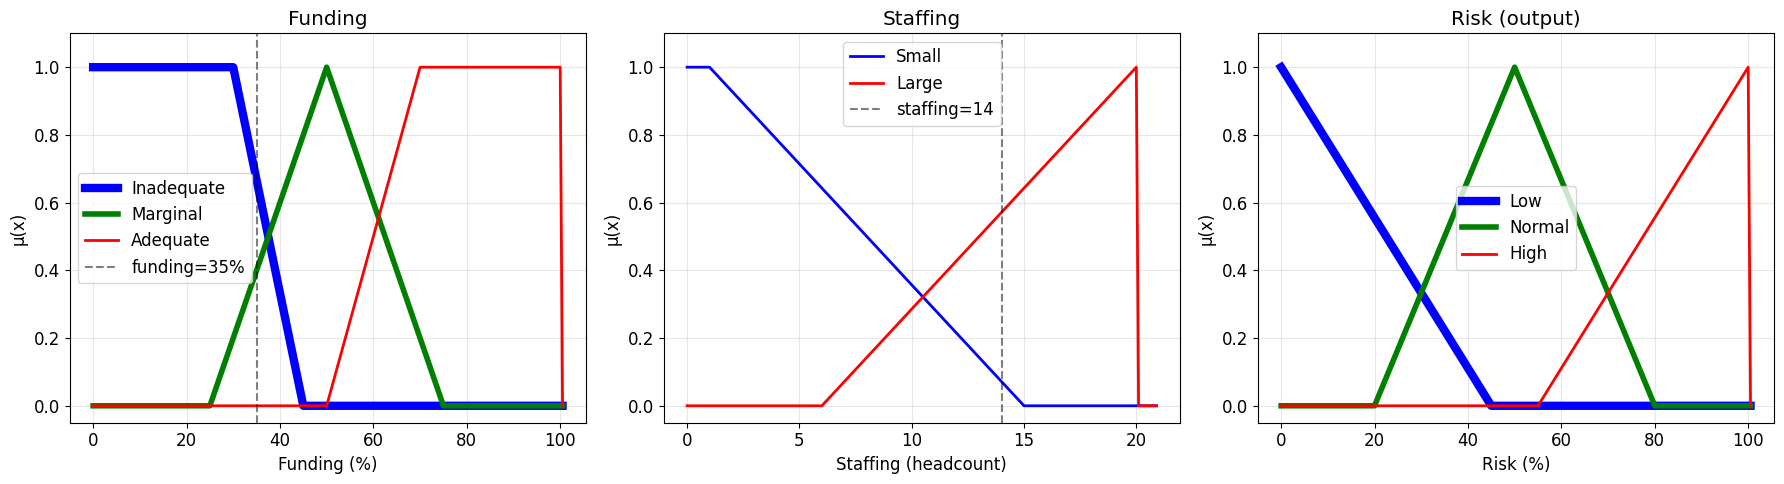

In [2]:
# Universes of discourse
x_fund = np.arange(0, 101, 0.5)
x_staff = np.arange(0, 21, 0.1)
x_risk = np.arange(0, 101, 0.5)

# --- Funding MFs ---
# Inadequate: (0,1)→(30,1)→(45,0) — trapezoidal left-shoulder
fund_inadequate = fuzz.trapmf(x_fund, [0, 0, 30, 45])

# Marginal: triangle (25, 50, 75)
fund_marginal = fuzz.trimf(x_fund, [25, 50, 75])
# Tip: use skfuzzy's "trimf" function

# Adequate: (50,0)→(70,1)→(100,1) — trapezoidal right-shoulder
fund_adequate = fuzz.trapmf(x_fund, [50, 70, 100, 100])

# --- Staffing MFs ---
# Small: (1,1)→(15,0) left-shoulder trapezoid
staff_small = fuzz.trapmf(x_staff, [0, 0, 1, 15])

# Large: (6,0)→(20,1) right-shoulder trapezoid
staff_large = fuzz.trapmf(x_staff, [6, 20, 20, 20])

# --- Risk MFs ---
# Low: (0,1)→(45,0) left-shoulder trapezoid
risk_low = fuzz.trapmf(x_risk, [0, 0, 0, 45])

# Normal: triangle (20, 50, 80)
risk_normal = fuzz.trimf(x_risk, [20, 50, 80])

# High: (55,0)→(100,1) right-shoulder trapezoid
risk_high = fuzz.trapmf(x_risk, [55, 100, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(x_fund, fund_inadequate, 'b-', lw=6, label='Inadequate')
ax1.plot(x_fund, fund_marginal, 'g-', lw=4, label='Marginal')
ax1.plot(x_fund, fund_adequate, 'r-', lw=2, label='Adequate')
ax1.axvline(x=35, color='k', ls='--', alpha=0.5, label='funding=35%')
ax1.set_title('Funding')
ax1.set_xlabel('Funding (%)')
ax1.set_ylabel('μ(x)')
ax1.legend()

ax2.plot(x_staff, staff_small, 'b-', lw=2, label='Small')
ax2.plot(x_staff, staff_large, 'r-', lw=2, label='Large')
ax2.axvline(x=14, color='k', ls='--', alpha=0.5, label='staffing=14')
ax2.set_title('Staffing')
ax2.set_xlabel('Staffing (headcount)')
ax2.set_ylabel('μ(x)')
ax2.legend()

ax3.plot(x_risk, risk_low, 'b-', lw=6, label='Low')
ax3.plot(x_risk, risk_normal, 'g-', lw=4, label='Normal')
ax3.plot(x_risk, risk_high, 'r-', lw=2, label='High')
ax3.set_title('Risk (output)')
ax3.set_xlabel('Risk (%)')
ax3.set_ylabel('μ(x)')
ax3.legend()

for ax in [ax1, ax2, ax3]:
				ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### Step 2: Fuzzification

Fuzzify the crisp inputs by evaluating each membership function at the input value.

The slides use **funding = 35%** and **staffing = 60%** (as percentage). However, since we are adopting staffing headcount (1–20) here, let's use **staffing = 14** (headcount). If you want to match the slides exactly later, use staffing as percentage and adjust the MFs accordingly.

In [3]:
# Crisp inputs
funding_val = 35
staffing_val = 14

# Fuzzify funding
# Calculate the degree of membership (DoM) for "inadequate"
mu_inadequate = fuzz.interp_membership(x_fund, fund_inadequate, funding_val)
mu_marginal = fuzz.interp_membership(x_fund, fund_marginal, funding_val)
mu_adequate = fuzz.interp_membership(x_fund, fund_adequate, funding_val)


# Fuzzify staffing

mu_small = fuzz.interp_membership(x_staff, staff_small, staffing_val)
mu_large = fuzz.interp_membership(x_staff, staff_large, staffing_val)

print(f"Fuzzification: funding = {funding_val}%, staffing = {staffing_val}")
print(f"{'─' * 45}")
print(f" μ_inadequate({funding_val}) = {mu_inadequate:.4f}")
print(f" μ_marginal({funding_val}) = {mu_marginal:.4f}")
print(f" μ_adequate({funding_val}) = {mu_adequate:.4f}")
print()
print(f" μ_small({staffing_val}) = {mu_small:.4f}")
print(f" μ_large({staffing_val}) = {mu_large:.4f}")

Fuzzification: funding = 35%, staffing = 14
─────────────────────────────────────────────
 μ_inadequate(35) = 0.6667
 μ_marginal(35) = 0.4000
 μ_adequate(35) = 0.0000

 μ_small(14) = 0.0714
 μ_large(14) = 0.5714


### Step 3: Rule Evaluation

Apply the fuzzy operators to evaluate each rule's antecedent, then **clip** (truncate) the consequent membership function at the rule's firing strength.

| Rule | Antecedent                              | Operator | Consequent    |
|------|-----------------------------------------|----------|---------------|
| 1    | funding IS adequate OR staffing IS small | max      | risk IS low   |
| 2    | funding IS marginal AND staffing IS large| min      | risk IS normal|
| 3    | funding IS inadequate                   | —        | risk IS high  |

The **implication** method clips the output MF at the rule's firing strength (Mamdani uses min-implication).

Rule evaluation:
 Rule 1: max(adequate=0.000, small=0.071) = 0.071 → clip 'low'
 Rule 2: min(marginal=0.400, large=0.571) = 0.400 → clip 'normal'
 Rule 3: inadequate = 0.667 → clip 'high'


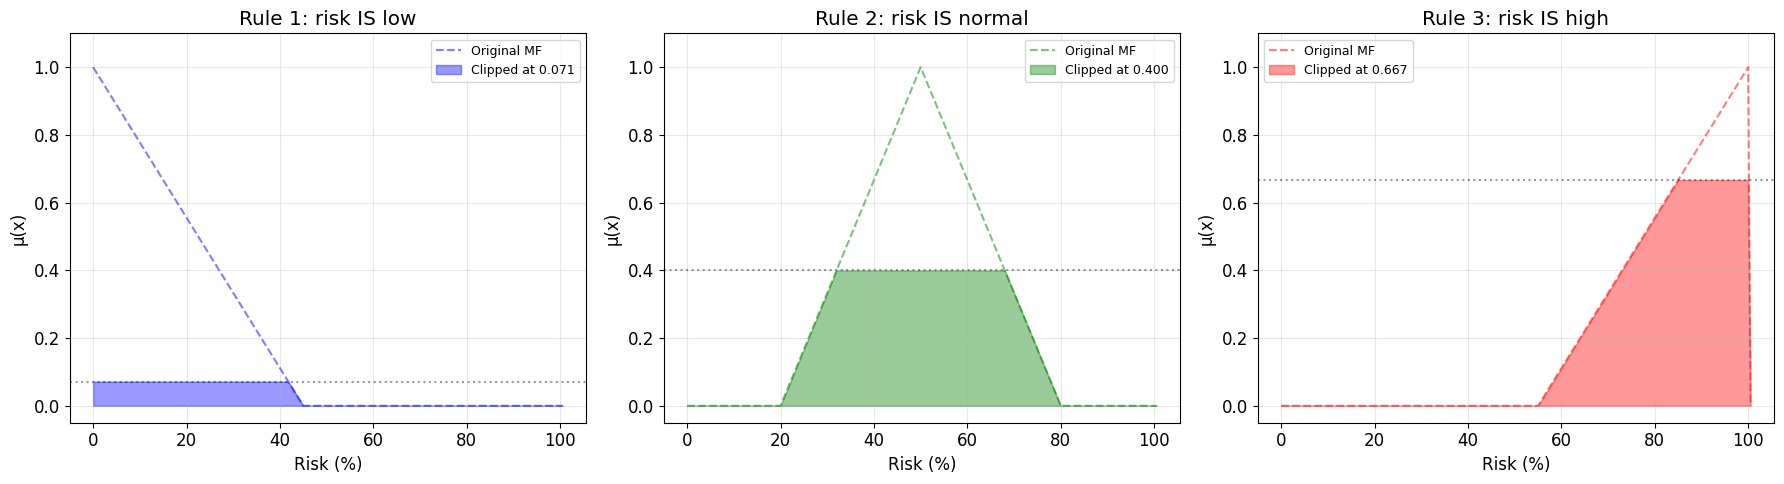

In [4]:
# Rule 1: IF funding IS adequate OR (max) staffing IS small THEN risk IS low
rule1_strength = max(mu_adequate, mu_small)
rule1_output = np.minimum(rule1_strength, risk_low) # Clip (min-implication)

# Rule 2: IF funding IS marginal AND (min) staffing IS large THEN risk IS normal
rule2_strength = min(mu_marginal, mu_large)
rule2_output = np.minimum(rule2_strength, risk_normal) # Clip

# Rule 3: IF funding IS inadequate THEN risk IS high
rule3_strength = mu_inadequate
rule3_output = np.minimum(rule3_strength, risk_high) # Clip

print("Rule evaluation:")
print(f" Rule 1: max(adequate={mu_adequate:.3f}, small={mu_small:.3f}) " \
 f"= {rule1_strength:.3f} → clip 'low'")
print(f" Rule 2: min(marginal={mu_marginal:.3f}, large={mu_large:.3f}) " \
 f"= {rule2_strength:.3f} → clip 'normal'")
print(f" Rule 3: inadequate = {rule3_strength:.3f} → clip 'high'")

# Plot clipped consequents
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Rule 1: risk IS low', 'Rule 2: risk IS normal', 'Rule 3: risk IS high']
originals = [risk_low, risk_normal, risk_high]
clipped = [rule1_output, rule2_output, rule3_output]
strengths = [rule1_strength, rule2_strength, rule3_strength]
colors = ['blue', 'green', 'red']

for ax, title, orig, clip, strength, color in zip(axes, titles, originals, clipped, strengths, colors):
     ax.plot(x_risk, orig, color=color, ls='--', lw=1.5, alpha=0.5, label='Original MF')
     ax.fill_between(x_risk, clip, alpha=0.4, color=color, label=f'Clipped at {strength:.3f}')
     ax.axhline(y=strength, color='k', ls=':', alpha=0.4)
     ax.set_title(title)
     ax.set_xlabel('Risk (%)')
     ax.set_ylabel('μ(x)')
     ax.set_ylim(-0.05, 1.1)
     ax.legend(fontsize=9)
     
plt.tight_layout()
plt.show()

### Step 4: Aggregation

Combine all clipped consequent MFs into a single fuzzy output set using the **maximum** operator (the most common aggregation method in Mamdani):

$$\mu_{aggregated}(z) = \max\left(\mu_{R1}(z),\, \mu_{R2}(z),\, \mu_{R3}(z)\right)$$

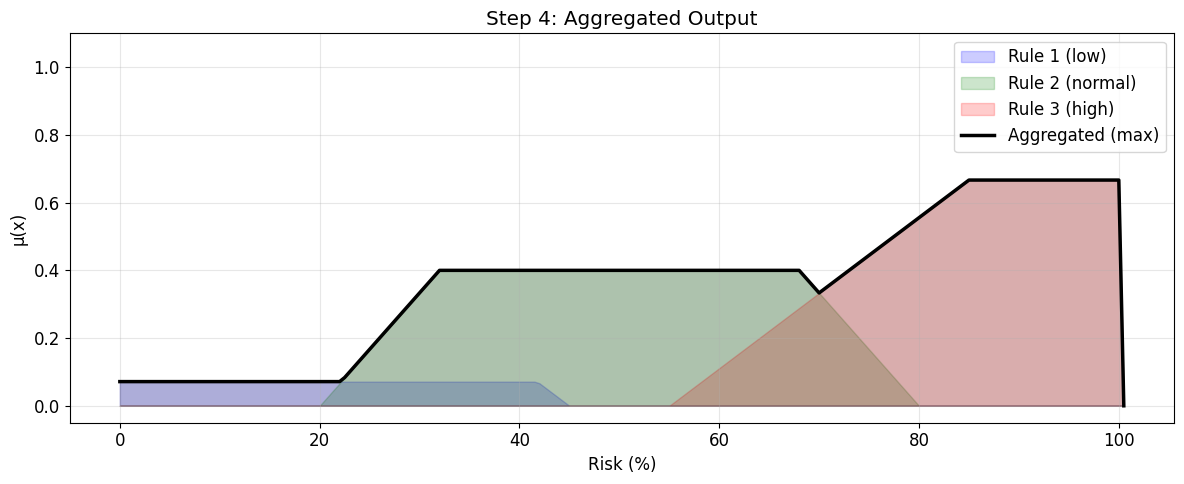

In [5]:
# Aggregate using max
aggregated = np.maximum.reduce([rule1_output, rule2_output, rule3_output])


# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_risk, rule1_output, alpha=0.2, color='blue', label='Rule 1 (low)')
ax.fill_between(x_risk, rule2_output, alpha=0.2, color='green', label='Rule 2 (normal)')
ax.fill_between(x_risk, rule3_output, alpha=0.2, color='red', label='Rule 3 (high)')
ax.plot(x_risk, aggregated, 'k-', lw=2.5, label='Aggregated (max)')
ax.fill_between(x_risk, aggregated, alpha=0.15, color='black')
ax.set_title('Step 4: Aggregated Output')
ax.set_xlabel('Risk (%)')
ax.set_ylabel('μ(x)')
ax.set_ylim(-0.05, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

### Step 5: Defuzzification

Convert the aggregated fuzzy output set into a single **crisp value**. We implement four methods:

| Method | Name               | Description                                                                 |
|--------|--------------------|-----------------------------------------------------------------------------|
| COG    | Centre of Gravity  | Weighted average of the output space: $z^* = \frac{\sum z \cdot \mu(z)}{\sum \mu(z)}$ |
| MOM    | Mean of Maxima     | Average of all $z$ values where $\mu(z)$ is maximum                         |
| SOM    | Smallest of Maxima | Smallest $z$ where $\mu(z)$ is maximum                                      |
| LOM    | Largest of Maxima  | Largest $z$ where $\mu(z)$ is maximum                                       |

Defuzzification results (funding=35%, staffing=14):
 COG (Centre of Gravity): 64.89%
 MOM (Mean of Maxima): 92.50%
 SOM (Smallest of Maxima): 85.00%
 LOM (Largest of Maxima): 100.00%


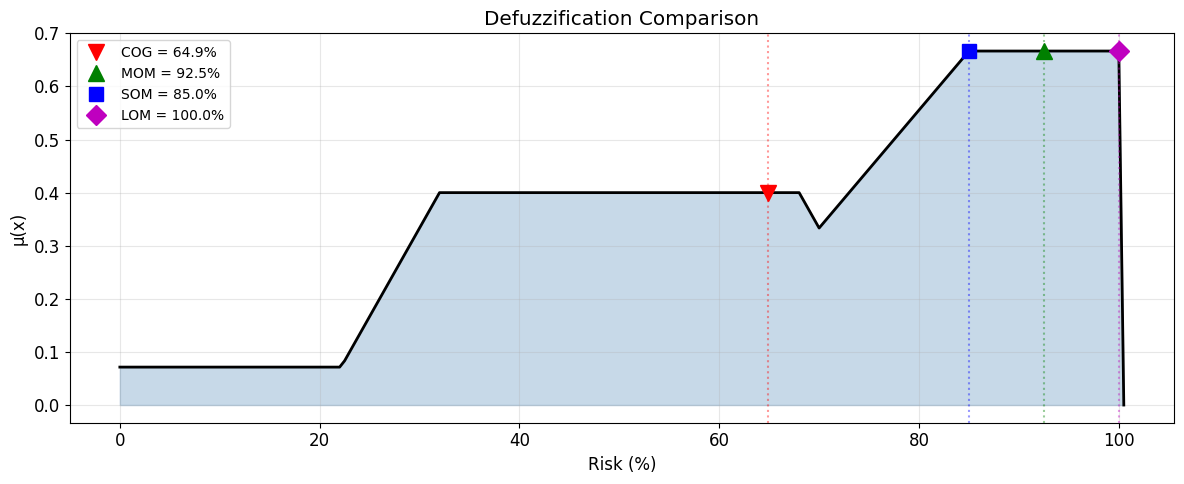

In [6]:
def defuzzify_cog(x, mf):
 """Centre of Gravity (centroid) defuzzification."""
 if np.sum(mf) == 0:
     return 0
 
 # Tip: See the COG equation in the MD cell above,
 # where "z" there is the "x" attribute here

 return np.sum(x * mf) / np.sum(mf)

def defuzzify_mom(x, mf):
 """Mean of Maxima defuzzification."""
 max_val = np.max(mf)
 if max_val == 0:
     return 0
 max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
 return np.mean(x[max_indices])

def defuzzify_som(x, mf):
 """Smallest of Maxima defuzzification."""
 max_val = np.max(mf)
 if max_val == 0:
     return 0
 max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
 return x[max_indices[0]]

def defuzzify_lom(x, mf):
 """Largest of Maxima defuzzification."""
 max_val = np.max(mf)
 if max_val == 0:
   return 0
 max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
 return x[max_indices[-1]]

# Compute all four
# Compute COG
cog = defuzzify_cog(x_risk, aggregated)

# Compute MOM
mom = defuzzify_mom(x_risk, aggregated)

# Compute SOM
som = defuzzify_som(x_risk, aggregated)

# Compute LOM
lom = defuzzify_lom(x_risk, aggregated)

print(f"Defuzzification results (funding={funding_val}%, staffing={staffing_val}):")
print(f" COG (Centre of Gravity): {cog:.2f}%")
print(f" MOM (Mean of Maxima): {mom:.2f}%")
print(f" SOM (Smallest of Maxima): {som:.2f}%")
print(f" LOM (Largest of Maxima): {lom:.2f}%")

# Plot with defuzzification points
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_risk, aggregated, alpha=0.3, color='steelblue')
ax.plot(x_risk, aggregated, 'k-', lw=2)

markers = {'COG': (cog, 'rv', 12), 'MOM': (mom, 'g^', 12),
           'SOM': (som, 'bs', 10), 'LOM': (lom, 'mD', 10)}

for name, (val, marker, ms) in markers.items():
   ax.plot(val, fuzz.interp_membership(x_risk, aggregated, val),
           marker, markersize=ms, label=f'{name} = {val:.1f}%')
   ax.axvline(x=val, color=marker[0], ls=':', alpha=0.4)
   
ax.set_title('Defuzzification Comparison')
ax.set_xlabel('Risk (%)')
ax.set_ylabel('μ(x)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## Part B: Fuzzy Inference with pyfuzzylite

Now we rebuild the same system using the **pyfuzzylite** library, which supports all three inference methods (Mamdani, Sugeno, Tsukamoto) and all defuzzification methods.

pyfuzzylite is the Python implementation of the FuzzyLite library family (also available in C++ and Java). Its rule syntax closely matches the natural-language style used in lectures and exams.

In [7]:
# pip install pyfuzzylite --no-deps
import fuzzylite as fl
from fuzzylite import settings
import warnings
# Suppress numpy deprecation warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Register custom hedges to match lecture slide definitions
settings.factory_manager.hedge.constructors["slightly"] = \
    lambda: fl.HedgeLambda("slightly", lambda x: x**1.7)

settings.factory_manager.hedge.constructors["a_little"] = \
    lambda: fl.HedgeLambda("a_little", lambda x: x**1.3)


settings.factory_manager.hedge.constructors["more_or_less"] = \
    lambda: fl.HedgeLambda("more_or_less", lambda x: x**0.5)


settings.factory_manager.hedge.constructors["extremely"] = \
    lambda: fl.HedgeLambda("extremely", lambda x: x**3)

# Register additional hedges from the slides
settings.factory_manager.hedge.constructors["very_very"] = \
    lambda: fl.HedgeLambda("very_very", lambda x: x**4)

# Built-in hedges that already match slides: very (x^2), somewhat (x^(1/3)), not (1-x)
print("Registered hedges:", list(settings.factory_manager.hedge.constructors.keys()))


Registered hedges: ['any', 'extremely', 'not', 'seldom', 'somewhat', 'very', 'slightly', 'a_little', 'more_or_less', 'very_very']


### B.1: Mamdani with pyfuzzylite — Project Staffing

Let's rebuild the project staffing system and verify it matches our from-scratch implementation.

In [8]:
# Project staffing Mamdani system
staffing_engine = fl.Engine(
    name="ProjectStaffing",
    input_variables=[
        fl.InputVariable(
            name="funding", minimum=0.0, maximum=100.0,
            terms=[
                fl.Trapezoid("inadequate", 0, 0, 30, 45),
                # TODO: using pyfuzzylite's "Triangle" function,
                #     define here the "Marginal" fuzzy set with
                #     the same parameters as in Part A, Step 1
                fl.Triangle("marginal", 25, 50, 75),

                # TODO: using pyfuzzylite's "Trapezoid" function,
                #     define here the "Adequate" fuzzy set with
                #     the same parameters as in Part A, Step 1
                fl.Trapezoid("adequate", 50, 70, 100, 100),
            ]
        ),
        fl.InputVariable(
            name="staffing", minimum=1.0, maximum=20.0,
            terms=[
                fl.Ramp("small", 15, 1),      # Descending: from 1(=1.0) to 15(=0.0)
                fl.Ramp("large", 6, 20),       # Ascending: from 6(=0.0) to 20(=1.0)
            ]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="risk", minimum=0.0, maximum=100.0,
            aggregation=fl.Maximum(),
            defuzzifier=fl.Centroid(500),
            terms=[
                fl.Ramp("low", 45, 0),            # Descending: from 0(=1.0) to 45(=0.0)
                # TODO: using pyfuzzylite's "Triangle" function,
                #     define here the "Normal" fuzzy set with
                #     the same parameters as in Part A, Step 1
                fl.Triangle("normal", 20, 50, 80),

                # TODO: using pyfuzzylite's "Ramp" function,
                #     define here the "High" fuzzy set with
                #     the same parameters as in Part A, Step 1
                # Ascending: from 55(=0.0) to 100(=1.0)
                fl.Ramp("high", 55, 100),
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),        # AND = min
            disjunction=fl.Maximum(),        # OR  = max
            implication=fl.Minimum(),        # Clip (min-implication)
            activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if funding is adequate or staffing is small "
                     "then risk is low")
                ),
                fl.Rule.create(
                    ("if funding is marginal and staffing is large "
                     "then risk is normal")
                ),
                fl.Rule.create("if funding is inadequate then risk is high"),
            ]
        ),
    ]
)

# Run inference
staffing_engine.input_variable("funding").value = 35.0
staffing_engine.input_variable("staffing").value = 14.0
staffing_engine.process()

pfl_cog = staffing_engine.output_variable("risk").value.item()
print(f"pyfuzzylite COG result: {pfl_cog:.2f}%")
print(f"From-scratch COG result: {cog:.2f}%")
print(f"Difference: {abs(pfl_cog - cog):.4f}%")

# Try all defuzzifiers
for name, defuzz in [("COG", fl.Centroid(500)), ("MOM", fl.MeanOfMaximum(500)),
                     ("SOM", fl.SmallestOfMaximum(500)), ("LOM", fl.LargestOfMaximum(500)),
                     ("Bisector", fl.Bisector(500))]:
    staffing_engine.output_variable("risk").defuzzifier = defuzz
    staffing_engine.process()
    val = staffing_engine.output_variable("risk").value.item()
    print(f"  {name:10s}: {val:.2f}%")

pyfuzzylite COG result: 64.76%
From-scratch COG result: 64.89%
Difference: 0.1281%
  COG       : 64.76%
  MOM       : 92.50%
  SOM       : 85.10%
  LOM       : 99.90%
  Bisector  : 67.90%


### B.2: Dapping Example — Mamdani with Hedges

Now the dapping example, complete with hedges.

**Rules:**

1. IF wind IS **extremely** stormy OR temperature IS **very** low THEN dapping IS **not very** poor
2. IF wind IS fresh AND temperature IS **more_or_less** average THEN dapping IS mediocre
3. IF wind IS **slightly** stormy AND temperature IS **not** low THEN dapping IS **a_little** excellent

In [9]:
dapping_engine = fl.Engine(
    name="Dapping",
    input_variables=[
        fl.InputVariable(
            name="wind", minimum=0.0, maximum=12.0,
            terms=[
                fl.Trapezoid("calm", 0, 0, 2, 5),
                fl.Triangle("fresh", 2, 6, 10),
                fl.Trapezoid("stormy", 6, 10, 12, 12),
            ]
        ),
        fl.InputVariable(
            name="temperature", minimum=0.0, maximum=30.0,
            terms=[
                # TODO: Define "low" set (1/0, 1/0 ,1/5 , 0/15)
                fl.Trapezoid("low", 0, 0, 5, 15),

                # TODO: Define "average" set (0/5, 1/15, 0/25)
                fl.Triangle("average", 5, 15, 25),

                # TODO: Define "high" set (0/18 ,1/24, 1/30, 1/30)
                fl.Trapezoid("high", 18, 24, 30, 30),
            ]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="dapping", minimum=0.0, maximum=100.0,
            aggregation=fl.Maximum(),
            defuzzifier=fl.Centroid(500),
            terms=[
                fl.Trapezoid("poor", 0, 0, 10, 30),
                fl.Triangle("mediocre", 20, 50, 80),
                fl.Trapezoid("excellent", 70, 90, 100, 100),
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),
            disjunction=fl.Maximum(),
            implication=fl.Minimum(),
            activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if wind is extremely stormy or temperature is very low "
                     "then dapping is not very poor")
                ),
                fl.Rule.create(
                    ("if wind is fresh and temperature is more_or_less average "
                     "then dapping is mediocre")
                ),
                fl.Rule.create(
                    ("if wind is slightly stormy and temperature is not low "
                     "then dapping is a_little excellent")
                ),
            ]
        ),
    ]
)

# Run with some crisp inputs
dapping_engine.input_variable("wind").value = 8.0
dapping_engine.input_variable("temperature").value = 10.0
dapping_engine.process()

mandani_cog = dapping_engine.output_variable("dapping").value.item()
print(f"Dapping Mamdani COG (wind=8, temp=10): {mandani_cog:.2f}%")
print()
print("All Mamdani defuzzifiers:")
for name, defuzz in [
    ("COG", fl.Centroid(500)), ("MOM", fl.MeanOfMaximum(500)),
    ("SOM", fl.SmallestOfMaximum(500)), ("LOM", fl.LargestOfMaximum(500))
]:
    dapping_engine.output_variable("dapping").defuzzifier = defuzz
    dapping_engine.process()
    val = dapping_engine.output_variable("dapping").value.item()
    print(f"  {name}: {val:.2f}%")

Dapping Mamdani COG (wind=8, temp=10): 38.29%

All Mamdani defuzzifiers:
  COG: 38.29%
  MOM: 5.60%
  SOM: 0.10%
  LOM: 11.10%


### B.3: Dapping Example — Sugeno Inference

In **Sugeno** (Takagi-Sugeno-Kang) inference, the consequent is a **constant or linear function** instead of a fuzzy set. Defuzzification uses a **weighted average** of the consequent values, weighted by the rule firing strengths:

$$z^* = \frac{\sum w_i \cdot z_i}{\sum w_i}$$

For zero-order Sugeno, each $z_i$ is a constant. Let's adopt these Sugeno singletons:

- Poor = 25, Mediocre = 50, Excellent = 75

In [10]:
# Dapping Sugeno (zero-order)
# The input variables (wind, temperature) are identical to the Mamdani engine above.
# Only the output variable differs: Sugeno uses singleton constants instead of fuzzy
# sets, and a weighted average defuzzifier instead of centroid.

dapping_sugeno = fl.Engine(
    name="DappingSugeno",
    input_variables=[
        # Same input MFs as the Mamdani engine
        fl.InputVariable(
            name="wind", minimum=0.0, maximum=12.0,
            terms=[t for t in dapping_engine.input_variable("wind").terms]
        ),
        fl.InputVariable(
            name="temperature", minimum=0.0, maximum=30,
            terms=[t for t in dapping_engine.input_variable("temperature").terms]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="dapping", minimum=0.0, maximum=100.0,
            aggregation=None,            # No aggregation for Sugeno
            defuzzifier=fl.WeightedAverage("TakagiSugeno"),
            terms=[
                fl.Constant("poor", 25),          # Singleton at 25
                fl.Constant("mediocre", 50),       # Singleton at 50
                fl.Constant("excellent", 75),      # Singleton at 75
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),
            disjunction=fl.Maximum(),
            implication=None,        # No implication for Sugeno
            activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if wind is extremely stormy or temperature "
                     "is very low then dapping is poor")
                ),
                fl.Rule.create(
                    ("if wind is fresh and temperature "
                     "is more_or_less average then dapping is mediocre")
                ),
                fl.Rule.create(
                    ("if wind is slightly stormy and temperature "
                     "is not low then dapping is a_little excellent")
                ),
            ]
        ),
    ]
)

dapping_sugeno.input_variable("wind").value = 8.0
dapping_sugeno.input_variable("temperature").value = 10.0
dapping_sugeno.process()

sugeno_result = dapping_sugeno.output_variable("dapping").value.item()
print(f"Dapping Sugeno (wind=8, temp=10): {sugeno_result:.2f}%")
print()

# Manual verification — compute firing strengths from the engine's own MFs
wind_val, temp_val = 8.0, 10.0

mu_stormy = fl.Trapezoid("stormy", 6, 10, 12, 12).membership(wind_val)
mu_fresh  = fl.Triangle("fresh", 2, 6, 10).membership(wind_val)
mu_low    = fl.Trapezoid("low", 0, 0, 5, 15).membership(temp_val)
mu_avg    = fl.Triangle("average", 5, 15, 25).membership(temp_val)

# Rule 1: extremely stormy OR very low → poor
ext_stormy = float(mu_stormy) ** 3
very_low   = float(mu_low) ** 2

w1 = max(ext_stormy, very_low)
# Rule 2: fresh AND more_or_less average → mediocre
mol_avg = float(mu_avg) ** 0.5
w2 = min(float(mu_fresh), mol_avg)
# Rule 3: slightly stormy AND NOT low → a_little excellent
sl_stormy = float(mu_stormy) ** 1.7
not_low   = 1 - float(mu_low)
r3_and    = min(sl_stormy, not_low)
w3 = r3_and ** 1.3

z1, z2, z3 = 25, 50, 75
manual_sugeno = (w1*z1 + w2*z2 + w3*z3) / (w1 + w2 + w3)
print("Manual Sugeno verification:")
print(
    (f"  Rule 1: w1 = {w1:.4f}  (extremely stormy={ext_stormy:.4f}, "
     f"very low={very_low:.4f})")
)
print(
    (f"  Rule 2: w2 = {w2:.4f}  (fresh={float(mu_fresh):.4f}, "
     f"mol avg={mol_avg:.4f})")
)
print(
    (f"  Rule 3: w3 = {w3:.4f}  (sl stormy={sl_stormy:.4f}, "
     f"not low={not_low:.4f}, a_little={w3:.4f})")
)
print(
    (f"  WA = ({w1:.3f}\u00d7{z1} + {w2:.3f}\u00d7{z2} + {w3:.3f}\u00d7{z3}) "
     f"/ ({w1:.3f} + {w2:.3f} + {w3:.3f})")
)
print(f"     = {w1*z1 + w2*z2 + w3*z3:.3f} / {w1+w2+w3:.3f}")
print(f"     = {manual_sugeno:.2f}%")
print(f"pyfuzzylite result: {sugeno_result:.2f}% ✓")

Dapping Sugeno (wind=8, temp=10): 49.12%

Manual Sugeno verification:
  Rule 1: w1 = 0.2500  (extremely stormy=0.1250, very low=0.2500)
  Rule 2: w2 = 0.5000  (fresh=0.5000, mol avg=0.7071)
  Rule 3: w3 = 0.2161  (sl stormy=0.3078, not low=0.5000, a_little=0.2161)
  WA = (0.250×25 + 0.500×50 + 0.216×75) / (0.250 + 0.500 + 0.216)
     = 47.460 / 0.966
     = 49.12%
pyfuzzylite result: 49.12% ✓


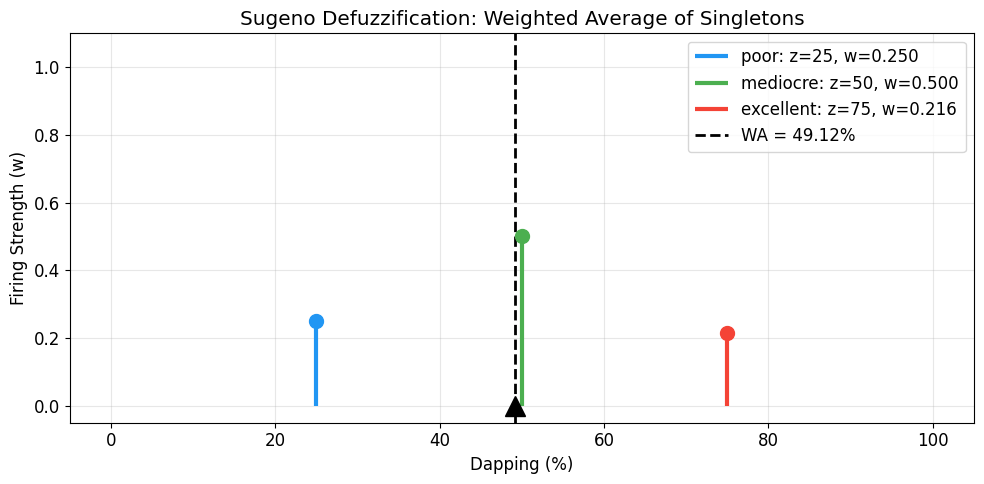

In [11]:
# --- Visualise Sugeno defuzzification ---
# Unlike Mamdani (which aggregates clipped fuzzy sets), Sugeno uses singletons
# weighted by rule firing strengths. The output is their weighted average.

fig, ax = plt.subplots(figsize=(10, 5))

# Singleton positions and firing strengths
singletons = {'Rule 1\npoor': (25, w1), 'Rule 2\nmediocre': (50, w2),
              'Rule 3\nexcellent': (75, w3)}
colors = ['#2196F3', '#4CAF50', '#F44336']

for (label, (z, w)), color in zip(singletons.items(), colors):
    # Vertical line from 0 to firing strength
    ax.vlines(z, 0, w, colors=color, linewidths=3,
              label=f'{label.split(chr(10))[1]}: z={z}, w={w:.3f}')
    ax.plot(z, w, 'o', color=color, markersize=10, zorder=5)

# Weighted average result
wa_sugeno = (w1*25 + w2*50 + w3*75) / (w1 + w2 + w3)
ax.axvline(x=wa_sugeno, color='black', ls='--', lw=2, label=f'WA = {wa_sugeno:.2f}%')
ax.plot(wa_sugeno, 0, 'k^', markersize=14, zorder=5)

ax.set_xlim(-5, 105)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('Dapping (%)')
ax.set_ylabel('Firing Strength (w)')
ax.set_title('Sugeno Defuzzification: Weighted Average of Singletons')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### B.4: Tsukamoto Inference with pyfuzzylite

**Tsukamoto** inference is similar to Sugeno but the consequent uses **monotonic membership functions** instead of constants. The crisp output $z_i$ for each rule is found by inverting the membership function at the rule's firing strength:

$$\mu_{C_i}(z_i) = w_i \quad \Rightarrow \quad z_i = \mu_{C_i}^{-1}(w_i)$$

The final output is a weighted average: $z^* = \frac{\sum w_i \cdot z_i}{\sum w_i}$

**Key requirement:** Output membership functions must be **monotonic** (always increasing or always decreasing). Triangles are NOT allowed — use Ramp, Sigmoid, or S/Z-shape functions.

**Note:** Because Tsukamoto requires monotonic output MFs, we approximate the dapping output variable's triangular MFs as Ramps. The results will differ from the from-scratch Mamdani and Sugeno sections (which use triangular outputs), but the method is the same. This is an inherent trade-off: Tsukamoto gains computational efficiency (no integration step) at the cost of output MF expressiveness.

In [12]:
# ================================================================
# B.4 – Tsukamoto Inference with pyfuzzylite
# ================================================================
# Tsukamoto output MFs MUST be monotonic (always increasing or always decreasing).
# pyfuzzylite enforces this by only allowing terms with a .tsukamoto() method:
# Ramp, Sigmoid, SShape, ZShape, and Concave.
#
# Below, we approximate the dapping output MFs as monotonic Ramps:
#   poor:      Ramp(30 → 0)  – decreasing  (μ=1 at x=0, μ=0 at x=30)
#   mediocre:  Ramp(20 → 80) – increasing   (μ=0 at x=20, μ=1 at x=80)
#   excellent: Ramp(50 → 100) – increasing  (μ=0 at x=50, μ=1 at x=100)
# ================================================================

print("=" * 65)
print("TSUKAMOTO INFERENCE – pyfuzzylite (dapping example)")
print("=" * 65)

# --- Build the Tsukamoto engine ---
# Input MFs: identical to the Mamdani/Sugeno engines.
# Output MFs: monotonic Ramp approximations.
# Rules: simplified (no hedges) – 4 rules from the old Java Lab 3.

tsukamoto_engine = fl.Engine(
    name="DappingTsukamoto",
    input_variables=[
        fl.InputVariable(name="wind", minimum=0.0, maximum=12,
            terms=[t for t in dapping_engine.input_variable("wind").terms]),
        fl.InputVariable(name="temperature", minimum=0, maximum=30,
            terms=[t for t in dapping_engine.input_variable("temperature").terms]),
    ],
    output_variables=[
        fl.OutputVariable(name="dapping", minimum=0, maximum=100,
            aggregation=None,
            defuzzifier=fl.WeightedAverage("Tsukamoto"),
            terms=[
                fl.Ramp("poor", 30, 0),          # decreasing
                fl.Ramp("mediocre", 20, 80),      # increasing
                fl.Ramp("excellent", 50, 100),     # increasing
            ]),
    ],
    rule_blocks=[
        fl.RuleBlock(name="rules",
            conjunction=fl.Minimum(), disjunction=fl.Maximum(),
            implication=fl.Minimum(), activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if wind is stormy or temperature is low "
                     "then dapping is poor")
                ),
                fl.Rule.create(
                    ("if wind is fresh and temperature is average "
                     "then dapping is mediocre")
                ),
                fl.Rule.create(
                    ("if wind is stormy or temperature is not low "
                     "then dapping is excellent")
                ),
                fl.Rule.create(
                    ("if wind is calm and temperature is not average "
                     "then dapping is poor")
                ),
            ]),
    ],
)

# --- Evaluate and trace through the computation ---
wind_val, temp_val = 8, 10
tsukamoto_engine.input_variable("wind").value = float(wind_val)
tsukamoto_engine.input_variable("temperature").value = float(temp_val)
tsukamoto_engine.process()
tsu_result = tsukamoto_engine.output_variable("dapping").value.item()

# Fuzzification (same as Mamdani/Sugeno)
mu_stormy = float(fl.Trapezoid("stormy", 6, 10, 12, 12).membership(wind_val))
mu_fresh  = float(fl.Triangle("fresh", 2, 6, 10).membership(wind_val))
mu_calm   = float(fl.Trapezoid("calm", 0, 0, 2, 5).membership(wind_val))
mu_low    = float(fl.Trapezoid("low", 0, 0, 5, 15).membership(temp_val))
mu_avg    = float(fl.Triangle("average", 5, 15, 25).membership(temp_val))

print(f"\nInputs: wind = {wind_val}, temperature = {temp_val}")
print(f"\nFuzzification:")
print(f"  μ_stormy({wind_val}) = {mu_stormy:.3f}    μ_low({temp_val})       = {mu_low:.3f}")
print(f"  μ_fresh({wind_val})  = {mu_fresh:.3f}    μ_average({temp_val})   = {mu_avg:.3f}")
print(f"  μ_calm({wind_val})   = {mu_calm:.3f}    μ_high({temp_val})      = 0.000")

# Rule evaluation (simplified – no hedges)
w1 = max(mu_stormy, mu_low)
w2 = min(mu_fresh, mu_avg)
w3 = max(mu_stormy, 1 - mu_low)
w4 = min(mu_calm, 1 - mu_avg)

print(f"\nRule firing strengths:")
print(f"  R1: stormy OR low      → w1 = max({mu_stormy:.3f}, {mu_low:.3f}) = {w1:.3f}")
print(f"  R2: fresh AND average  → w2 = min({mu_fresh:.3f}, {mu_avg:.3f}) = {w2:.3f}")
print(f"  R3: stormy OR NOT low  → w3 = max({mu_stormy:.3f}, {1-mu_low:.3f}) = {w3:.3f}")
print(f"  R4: calm AND NOT avg   → w4 = min({mu_calm:.3f}, {1-mu_avg:.3f}) = {w4:.3f}")

# Tsukamoto: invert monotonic output MFs
poor_mf = fl.Ramp("poor", 30, 0)
med_mf  = fl.Ramp("mediocre", 20, 80)
exc_mf  = fl.Ramp("excellent", 50, 100)

z1 = float(poor_mf.tsukamoto(w1))
z2 = float(med_mf.tsukamoto(w2))
z3 = float(exc_mf.tsukamoto(w3))
z4 = float(poor_mf.tsukamoto(w4))

print(f"\nTsukamoto step – invert monotonic output MFs at each firing strength:")
print(f"  R1 = poor:      μ_poor(z1) = {w1:.3f}  ⇒  z1 = {z1:.2f}")
print(f"  R2 = mediocre:  μ_med(z2)  = {w2:.3f}  ⇒  z2 = {z2:.2f}")
print(f"  R3 = excellent: μ_exc(z3)  = {w3:.3f}  ⇒  z3 = {z3:.2f}")
print(
    (f"  R4 = poor:      μ_poor(z4) = {w4:.3f}  ⇒  z4 = {z4:.2f} "
     f"{'(w4=0, excluded)' if w4 < 0.001 else ''}")
)

# Weighted average (only non-zero weights)
active = [(w, z) for w, z in [(w1,z1),(w2,z2),(w3,z3),(w4,z4)] if w > 0.001]
num = sum(w*z for w, z in active)
den = sum(w for w, _ in active)
wa = num / den

print(f"\nWeighted average (Tsukamoto defuzzification):")
terms = " + ".join(f"{w:.3f}×{z:.2f}" for w, z in active)
weights = " + ".join(f"{w:.3f}" for w, _ in active)
print(f"  = ({terms}) / ({weights})")
print(f"  = {num:.3f} / {den:.3f}")
print(f"  = {wa:.2f}%")
print(f"pyfuzzylite result: {tsu_result:.2f}% ✓")

print(f"\n{'='*65}")
print(f"COMPARISON: Mamdani vs Sugeno vs Tsukamoto (wind={wind_val}, temp={temp_val})")
print(f"{'='*65}")
print(f"Note: The three methods use different output representations and")
print(f"different rule sets (B.2/B.3 use hedged rules; B.4 uses simplified")
print(f"rules without hedges), so numerical differences are expected.")

TSUKAMOTO INFERENCE – pyfuzzylite (dapping example)

Inputs: wind = 8, temperature = 10

Fuzzification:
  μ_stormy(8) = 0.500    μ_low(10)       = 0.500
  μ_fresh(8)  = 0.500    μ_average(10)   = 0.500
  μ_calm(8)   = 0.000    μ_high(10)      = 0.000

Rule firing strengths:
  R1: stormy OR low      → w1 = max(0.500, 0.500) = 0.500
  R2: fresh AND average  → w2 = min(0.500, 0.500) = 0.500
  R3: stormy OR NOT low  → w3 = max(0.500, 0.500) = 0.500
  R4: calm AND NOT avg   → w4 = min(0.000, 0.500) = 0.000

Tsukamoto step – invert monotonic output MFs at each firing strength:
  R1 = poor:      μ_poor(z1) = 0.500  ⇒  z1 = 15.00
  R2 = mediocre:  μ_med(z2)  = 0.500  ⇒  z2 = 50.00
  R3 = excellent: μ_exc(z3)  = 0.500  ⇒  z3 = 75.00
  R4 = poor:      μ_poor(z4) = 0.000  ⇒  z4 = 30.00 (w4=0, excluded)

Weighted average (Tsukamoto defuzzification):
  = (0.500×15.00 + 0.500×50.00 + 0.500×75.00) / (0.500 + 0.500 + 0.500)
  = 70.000 / 1.500
  = 46.67%
pyfuzzylite result: 46.67% ✓

COMPARISON: Mamdan

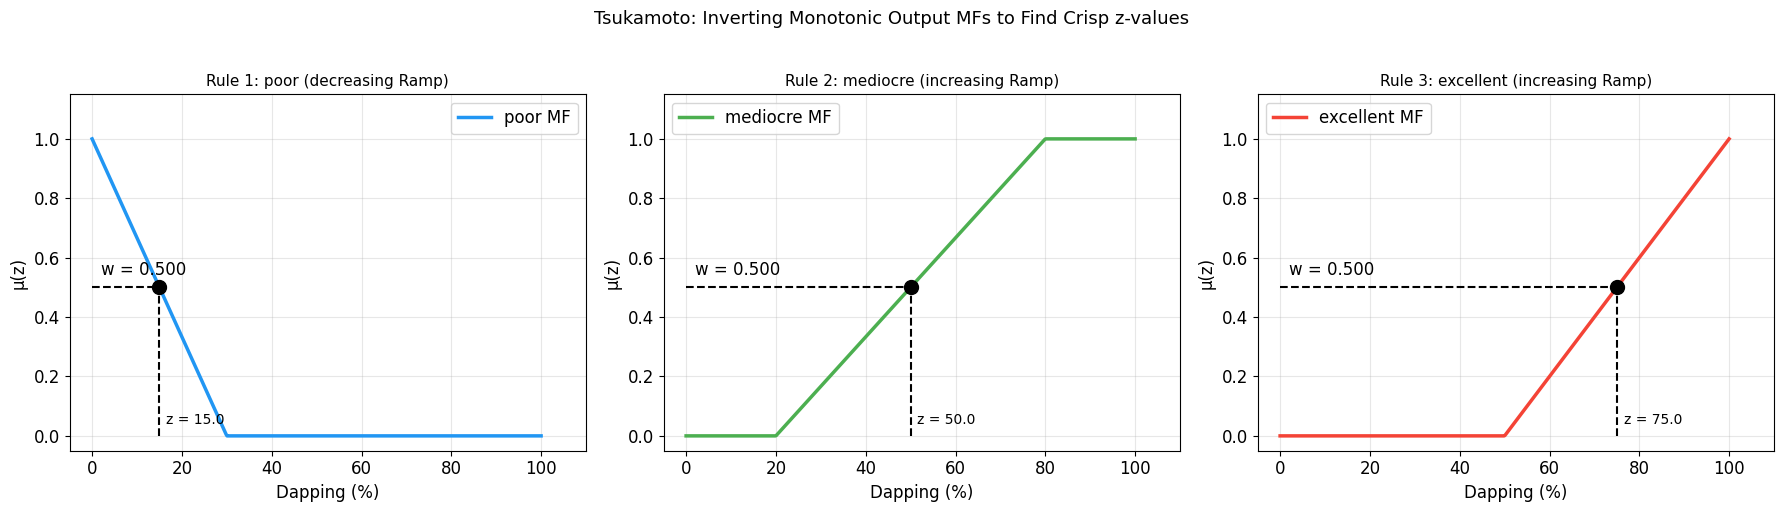

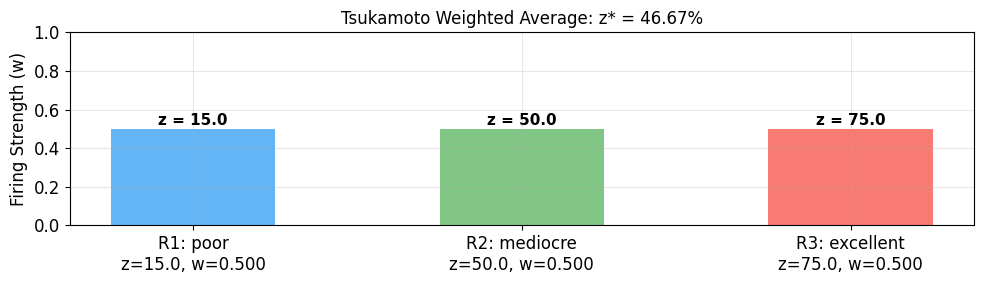

In [13]:
# --- Visualise Tsukamoto defuzzification: MF inversion ---
# Each rule's crisp output z_i is found by inverting the monotonic output MF
# at the rule's firing strength: μ(z_i) = w_i → z_i = μ⁻¹(w_i)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rule data: (title, Ramp params, firing strength, z-value, color)
rules_data = [
    ('Rule 1: poor (decreasing Ramp)', poor_mf, w1, z1, '#2196F3'),
    ('Rule 2: mediocre (increasing Ramp)', med_mf, w2, z2, '#4CAF50'),
    ('Rule 3: excellent (increasing Ramp)', exc_mf, w3, z3, '#F44336'),
]

for ax, (title, mf, w, z, color) in zip(axes, rules_data):
    # Plot the monotonic MF
    x_out = np.linspace(0, 100, 500)
    y_out = np.array([float(mf.membership(xi)) for xi in x_out])
    ax.plot(x_out, y_out, color=color, lw=2.5, label=f'{mf.name} MF')

    if w > 0.001:  # Only show inversion for non-zero firing strengths
        # Horizontal line at firing strength w
        ax.hlines(w, 0, z, colors='black', linestyles='--', lw=1.5)
        # Vertical line dropping down to z on x-axis
        ax.vlines(z, 0, w, colors='black', linestyles='--', lw=1.5)
        # Mark the intersection point
        ax.plot(z, w, 'ko', markersize=10, zorder=5)
        # Annotate
        ax.annotate(f'w = {w:.3f}', xy=(2, w + 0.04), fontsize=12, color='black')
        ax.annotate(f'z = {z:.1f}', xy=(z + 1.5, 0.04), fontsize=10, color='black')

    ax.set_xlim(-5, 110)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel('Dapping (%)')
    ax.set_ylabel('μ(z)')
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper right' if 'decreasing' in title else 'upper left')

plt.suptitle('Tsukamoto: Inverting Monotonic Output MFs to Find Crisp z-values',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary bar showing weighted average ---
fig, ax = plt.subplots(figsize=(10, 3))

weights = [w1, w2, w3]
z_vals = [z1, z2, z3]
labels = [f'R1: poor\nz={z1:.1f}, w={w1:.3f}',
          f'R2: mediocre\nz={z2:.1f}, w={w2:.3f}',
          f'R3: excellent\nz={z3:.1f}, w={w3:.3f}']
bar_colors = ['#2196F3', '#4CAF50', '#F44336']

bars = ax.bar(labels, weights, color=bar_colors, alpha=0.7, width=0.5)
# Show z values as text on bars
for bar, z_val in zip(bars, z_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'z = {z_val:.1f}', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=0, color='black', lw=0.5)
ax.set_ylabel('Firing Strength (w)')
ax.set_title(f'Tsukamoto Weighted Average: z* = {wa:.2f}%', fontsize=12)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### B.5: 3D Surface Plots — Mamdani vs Sugeno

Surface plots show the **complete input-output mapping** of a fuzzy system.

For each point on the (wind, temperature) grid we run the engine and record the output.

We'll compare:
- **Mamdani** (Centroid defuzzification) — smooth but computationally heavier
- **Sugeno** (Weighted Average) — crisp singleton outputs, faster

Computing Mamdani surface …
Computing Sugeno surface …
Done!


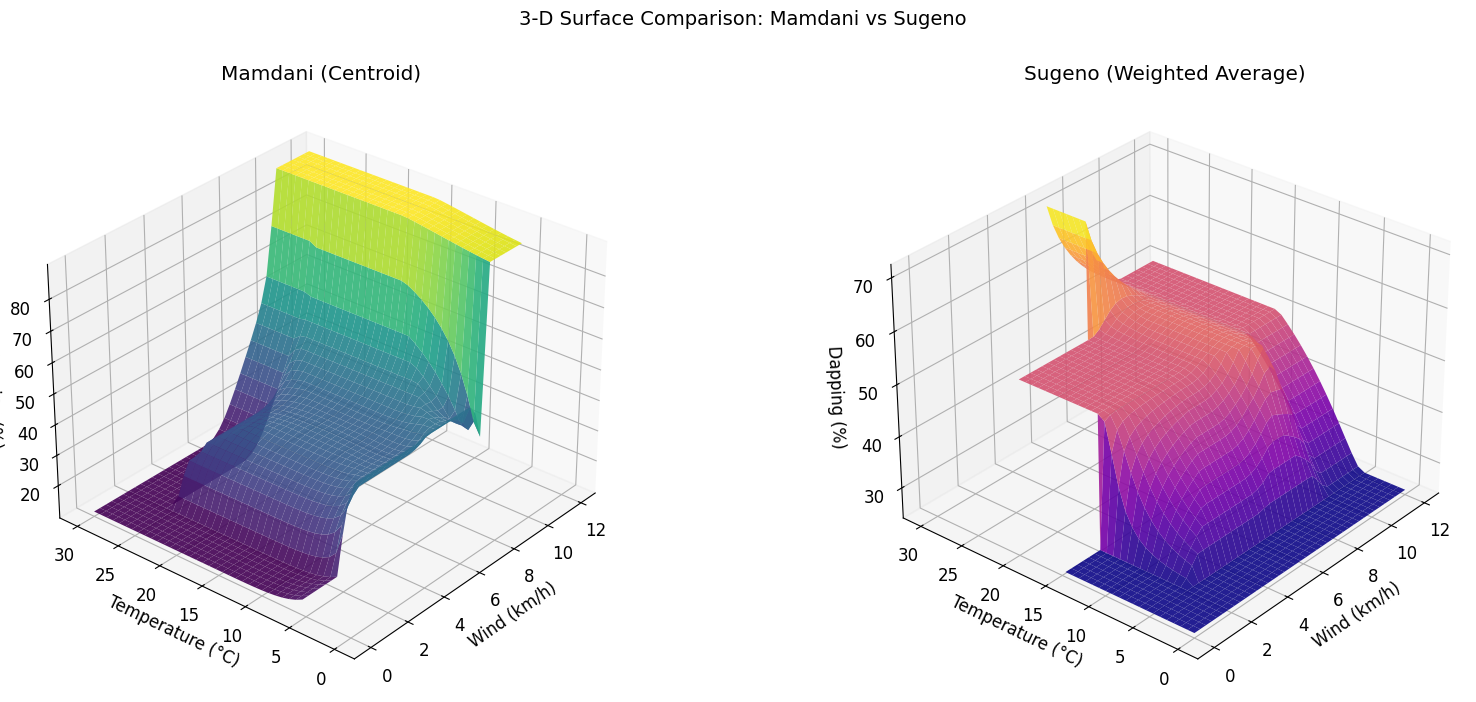

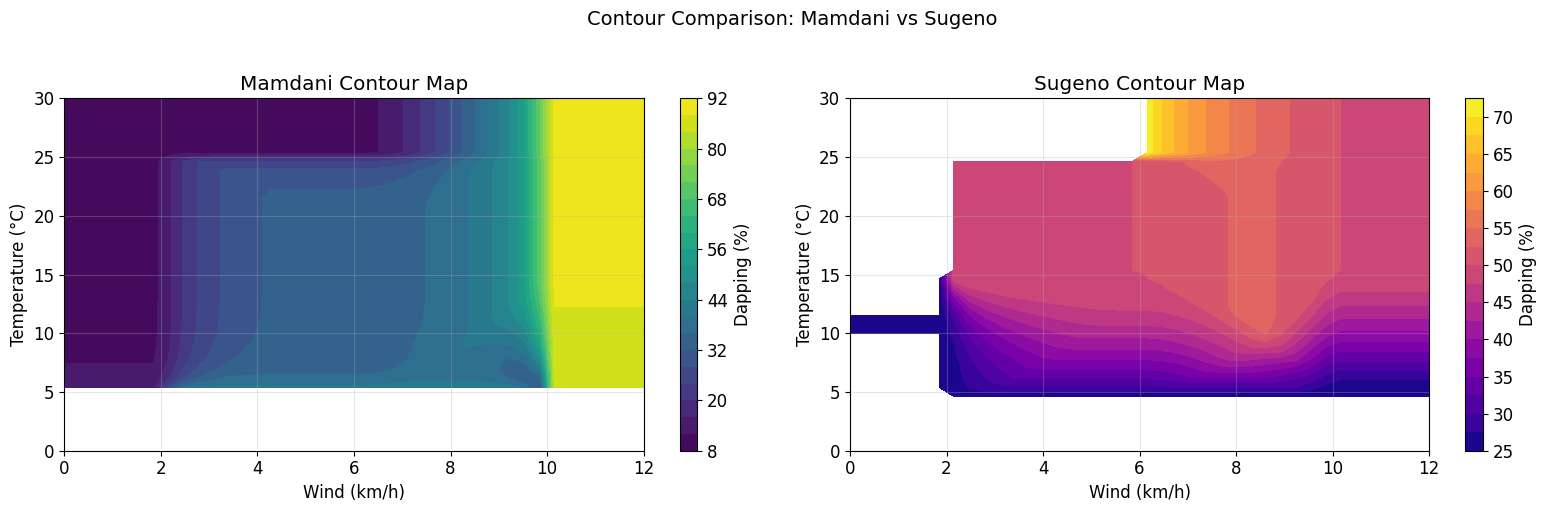

In [14]:
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------------
# Helper: sweep two inputs through an engine, collect the output
# ------------------------------------------------------------------
def compute_surface(engine, in1_name, in2_name, out_name, n=40):
    """Return X1, X2, Z arrays for a 3-D surface plot."""
    iv1 = engine.input_variable(in1_name)
    iv2 = engine.input_variable(in2_name)
    ov  = engine.output_variable(out_name)

    x1 = np.linspace(iv1.minimum, iv1.maximum, n)
    x2 = np.linspace(iv2.minimum, iv2.maximum, n)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.full_like(X1, np.nan)

    for i in range(n):
        for j in range(n):
            iv1.value = float(X1[i, j])
            iv2.value = float(X2[i, j])
            engine.process()
            z_val = ov.value
            if not (z_val is None or np.isnan(z_val) or np.isinf(z_val)):
                Z[i, j] = z_val

    return X1, X2, Z

# --- Compute surfaces ---
# Make sure Mamdani uses Centroid
dapping_engine.output_variable("dapping").defuzzifier = fl.Centroid(200)

print("Computing Mamdani surface …")
X1m, X2m, Zm = compute_surface(dapping_engine, "wind", "temperature",
                                "dapping", n=40)
print("Computing Sugeno surface …")
X1s, X2s, Zs = compute_surface(dapping_sugeno, "wind", "temperature",
                                "dapping", n=40)
print("Done!")

# ------------------------------------------------------------------
# 3-D Surface Plots
# ------------------------------------------------------------------
fig = plt.figure(figsize=(18, 7))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1m, X2m, Zm, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel('Wind (km/h)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_zlabel('Dapping (%)')
ax1.set_title('Mamdani (Centroid)')
ax1.view_init(elev=30, azim=220)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X1s, X2s, Zs, cmap='plasma', edgecolor='none', alpha=0.9)
ax2.set_xlabel('Wind (km/h)')
ax2.set_ylabel('Temperature (°C)')
ax2.set_zlabel('Dapping (%)')
ax2.set_title('Sugeno (Weighted Average)')
ax2.view_init(elev=30, azim=220)

plt.suptitle('3-D Surface Comparison: Mamdani vs Sugeno', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Contour Maps
# ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

c1 = ax1.contourf(X1m, X2m, Zm, levels=20, cmap='viridis')
fig.colorbar(c1, ax=ax1, label='Dapping (%)')
ax1.set_xlabel('Wind (km/h)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Mamdani Contour Map')

c2 = ax2.contourf(X1s, X2s, Zs, levels=20, cmap='plasma')
fig.colorbar(c2, ax=ax2, label='Dapping (%)')
ax2.set_xlabel('Wind (km/h)')
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Sugeno Contour Map')

plt.suptitle('Contour Comparison: Mamdani vs Sugeno', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## Summary

In this lab we:

1. **Built a Mamdani system from scratch** using `scikit-fuzzy` — defining membership functions, fuzzifying inputs, evaluating rules, aggregating, and defuzzifying with multiple methods (COG, MOM, SOM, LOM, Bisector).
2. **Replicated it with `pyfuzzylite`** (Project Staffing example) — same logic expressed declaratively in a few lines of FLL.
3. **Added linguistic hedges** (`very`, `somewhat`, `slightly`, `extremely`, etc.) to see how they sharpen or broaden membership functions.
4. **Implemented Sugeno inference** — singleton consequents, manual weighted-average verification.
5. **Implemented Tsukamoto inference** — monotonic output MFs, algebraic inversion, and weighted-average aggregation.
6. **Compared Mamdani vs Sugeno** via 3-D surface plots and contour maps.

| Feature | Mamdani | Sugeno | Tsukamoto |
|---|---|---|---|
| **Output MFs** | Fuzzy sets (triangles, traps …) | Singletons or linear functions | Monotonic MFs (Ramp, Sigmoid) |
| **Aggregation** | Max / Sum of fuzzy sets | Weighted Average of crisp values | Weighted Average of crisp values |
| **Defuzzification** | Centroid, Bisector, MOM … | Built-in (WA) | Built-in (WA after inversion) |
| **Interpretability** | ★★★ High | ★★ Medium | ★★ Medium |
| **Computation** | Heavier (area-based) | Lighter (algebraic) | Moderate (inversion step) |

### Preparation for Lab 3
The concepts explored here — membership functions, fuzzification, rule evaluation, and defuzzification — form the foundation for **neuro-fuzzy systems** (e.g., ANFIS) that we will encounter later. Understanding the differences between Mamdani, Sugeno, and Tsukamoto is essential for choosing the right architecture when combining neural networks with fuzzy logic.